In [ ]:
#PRICER D'OPTIONS EUROPÉENNES - S&P500
#Black-Scholes / Grecques / Monte Carlo


#1. Imports
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

#2. Black-Scoles
def black_scholes (S, K, T, r, sigma, option_type="call") :
 d1= (np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
 d2= d1-sigma*np.sqrt(T)
 C=S*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)
 P=K*np.exp(-r*T)*norm.cdf(-d2)-S*norm.cdf(-d1)

 if option_type=="call" :
      return C
 else : 
      return P

S = 6740
K = 6740
T = 1
r = 0.0375
sigma = 0.25

call = black_scholes(S, K, T, r, sigma, "call")
put = black_scholes(S, K, T, r, sigma, "put")

print(f"Prix du call : {call:.2f}$")
print(f"Prix du Put : {put:.2f}$")


Prix du call : 789.52$
Prix du Put : 541.45$


In [ ]:
#3. Prix du call et put
print(f"Call - Put : {call - put:.2f}$")
print(f"S - K*e^(-rT) : {S - K*np.exp(-r*T):.2f}$")

Call - Put : 248.07$
S - K*e^(-rT) : 248.07$


In [ ]:
#4. Calcul des Grecques
def greeks(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2/2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    delta_call = norm.cdf(d1)
    delta_put = norm.cdf(d1)-1
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T)
    theta_call = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))) - (r * K * np.exp(-r*T) * norm.cdf(d2))
    theta_put = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))) + (r * K * np.exp(-r*T) * norm.cdf(-d2))
    rho_call = K * T * np.exp(-r*T) * norm.cdf(d2)
    rho_put = -K * T * np.exp(-r*T) * norm.cdf(-d2)

    return delta_call, delta_put, gamma, vega, theta_call, theta_put, rho_call, rho_put

delta_c, delta_p, gamma, vega, theta_c, theta_p, rho_c, rho_p = greeks(S, K, T, r, sigma)

print(f"Delta Call : {delta_c:.4f}")
print(f"Delta Put : {delta_p:.4f}")
print(f"Gamma : {gamma:.6f}")
print(f"Vega : {vega:.2f}")
print(f"Theta Call : {theta_c:.2f}")
print(f"Theta Put : {theta_p:.2f}")
print(f"Rho Call : {rho_c:.2f}")
print(f"Rho Put : {rho_p:.2f}")


Delta Call : 0.6083
Delta Put : -0.3917
Gamma : 0.000228
Vega : 2589.10
Theta Call : -447.79
Theta Put : -204.34
Rho Call : 3310.71
Rho Put : -3181.22


In [ ]:
#Prix du call et put Monte Carlo et Black-Scholes
N = 1000

Z = np.random.standard_normal(N)
ST = S * np.exp((r - sigma**2/2) * T + sigma * np.sqrt(T) * Z)

payoff_call = np.maximum(ST - K, 0)
payoff_put = np.maximum(K - ST, 0)

call_mc = np.exp(-r*T) * np.mean(payoff_call)
put_mc = np.exp(-r*T) * np.mean(payoff_put)

print(f"Prix Call Monte Carlo : {call_mc:.2f}$")
print(f"Prix Call Black-Scholes : {black_scholes(S, K, T, r, sigma, 'call'):.2f}$")
print(f"Prix Put Monte Carlo : {put_mc:.2f}$")
print(f"Prix Put Black-Scholes : {black_scholes(S, K, T, r, sigma, 'put'):.2f}$")

Prix Call Monte Carlo : 781.90$
Prix Call Black-Scholes : 789.52$
Prix Put Monte Carlo : 549.87$
Prix Put Black-Scholes : 541.45$


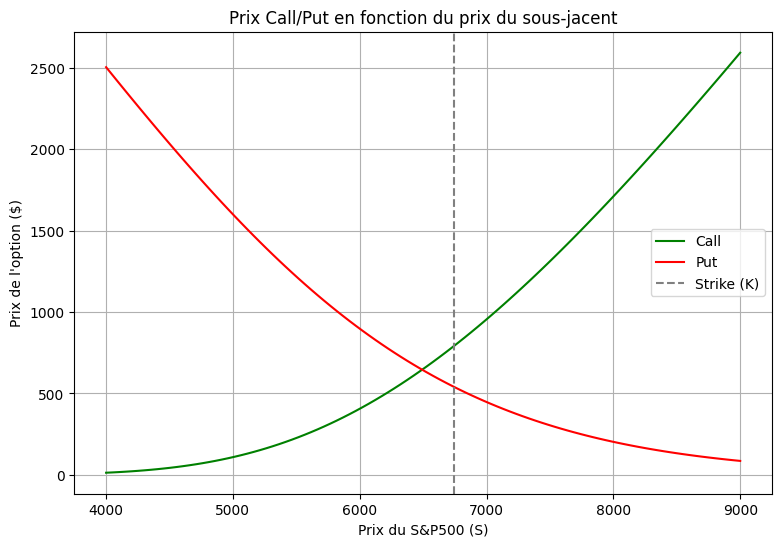

In [ ]:
#5. Visualisations 
import matplotlib.pyplot as plt
import numpy as np

S_range = np.linspace(4000, 9000, 100)
calls = [black_scholes(s, K, T, r, sigma, "call") for s in S_range]
puts = [black_scholes(s, K, T, r, sigma, "put") for s in S_range]

plt.figure(figsize=(9, 6))
plt.plot(S_range, calls, color='green', label='Call')
plt.plot(S_range, puts, color='red', label='Put')
plt.axvline(x=K, color='grey', linestyle='--', label='Strike (K)')
plt.title("Prix Call/Put en fonction du prix du sous-jacent")
plt.xlabel("Prix du S&P500 (S)")
plt.ylabel("Prix de l'option ($)")
plt.legend()
plt.grid(True)
plt.show()

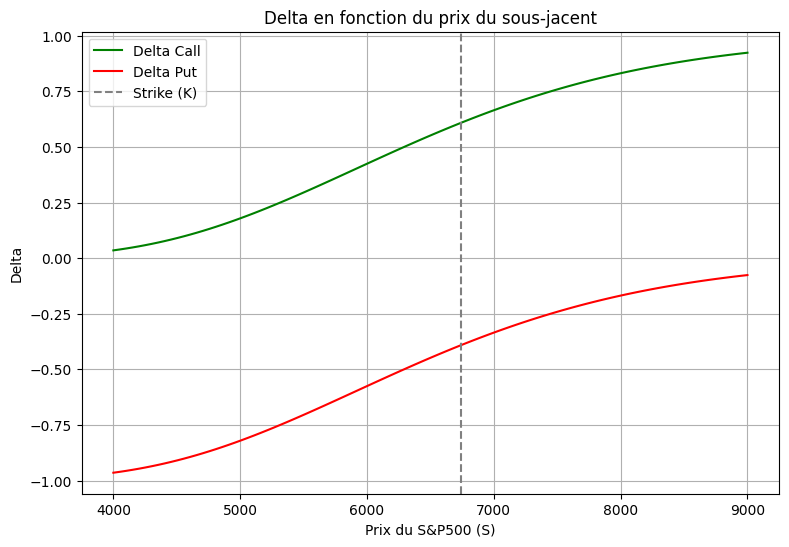

In [19]:
deltas_call = [greeks(s, K, T, r, sigma)[0] for s in S_range]
deltas_put = [greeks(s, K, T, r, sigma)[1] for s in S_range]

plt.figure(figsize=(9, 6))
plt.plot(S_range, deltas_call, color='green', label='Delta Call')
plt.plot(S_range, deltas_put, color='red', label='Delta Put')
plt.axvline(x=K, color='grey', linestyle='--', label='Strike (K)')
plt.title("Delta en fonction du prix du sous-jacent")
plt.xlabel("Prix du S&P500 (S)")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
plt.show()

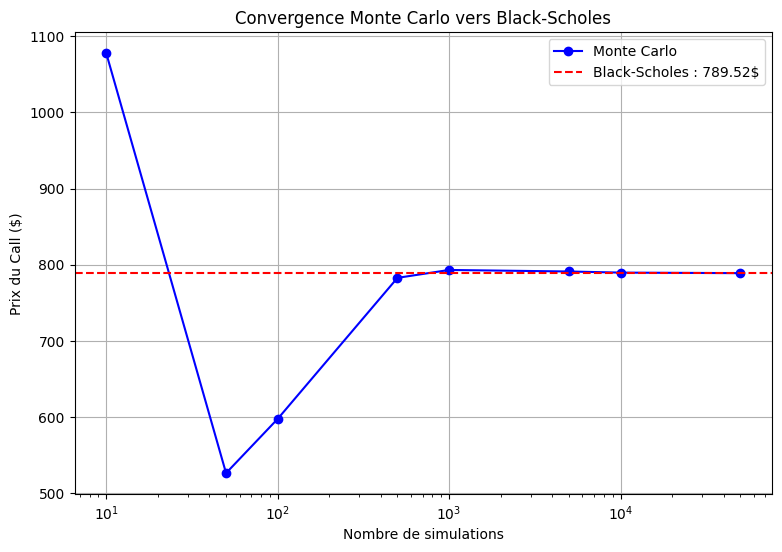

In [20]:
simulations = [10, 50, 100, 500, 1000, 5000, 10000, 50000]
mc_prices = []
bs_price = black_scholes(S, K, T, r, sigma, "call")

for N in simulations:
    np.random.seed(42)
    Z = np.random.standard_normal(N)
    ST = S * np.exp((r - sigma**2/2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    mc_prices.append(np.exp(-r*T) * np.mean(payoff))

plt.figure(figsize=(9, 6))
plt.plot(simulations, mc_prices, color='blue', marker='o', label='Monte Carlo')
plt.axhline(y=bs_price, color='red', linestyle='--', label=f'Black-Scholes : {bs_price:.2f}$')
plt.xscale('log')
plt.title("Convergence Monte Carlo vers Black-Scholes")
plt.xlabel("Nombre de simulations")
plt.ylabel("Prix du Call ($)")
plt.legend()
plt.grid(True)
plt.show()

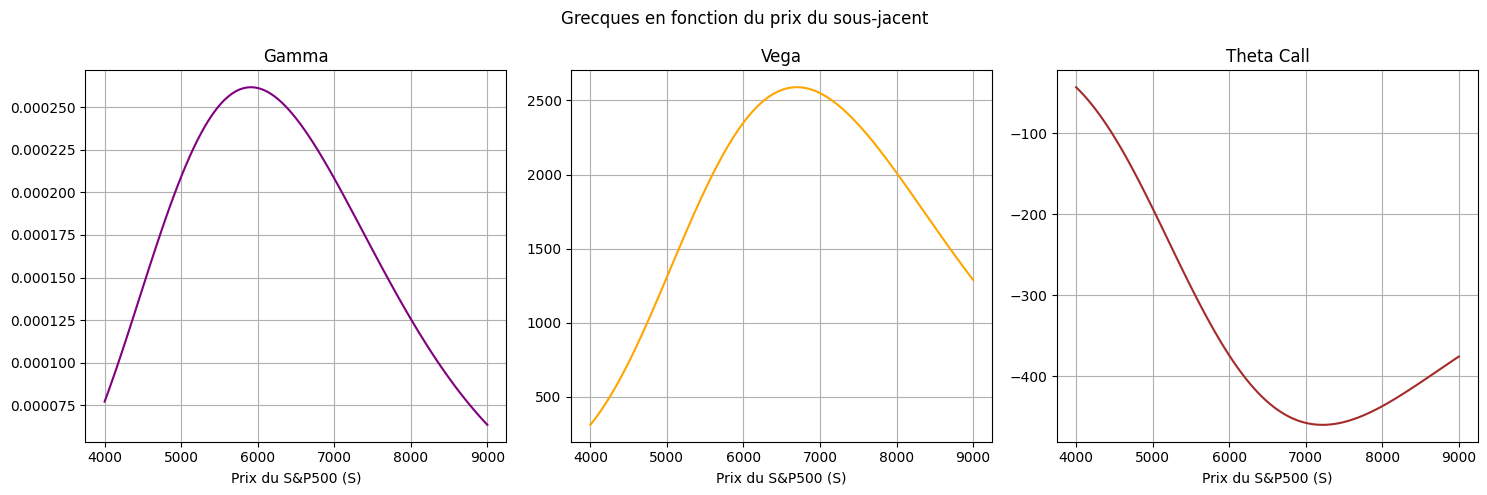

In [21]:
gammas = [greeks(s, K, T, r, sigma)[2] for s in S_range]
vegas = [greeks(s, K, T, r, sigma)[3] for s in S_range]
thetas_call = [greeks(s, K, T, r, sigma)[4] for s in S_range]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(S_range, gammas, color='purple')
axes[0].set_title("Gamma")
axes[0].set_xlabel("Prix du S&P500 (S)")
axes[0].grid(True)

axes[1].plot(S_range, vegas, color='orange')
axes[1].set_title("Vega")
axes[1].set_xlabel("Prix du S&P500 (S)")
axes[1].grid(True)

axes[2].plot(S_range, thetas_call, color='brown')
axes[2].set_title("Theta Call")
axes[2].set_xlabel("Prix du S&P500 (S)")
axes[2].grid(True)

plt.suptitle("Grecques en fonction du prix du sous-jacent")
plt.tight_layout()
plt.show()